<a href="https://colab.research.google.com/github/HeatherNankunda/electric-vehicle-energy-demand-forecasting/blob/main/Final_Project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Electric_Vehicle_(EV)_Charging_Data_-_Municipal_Lots_and_Garages_20260406.csv")

In [ ]:
df.head()

,Date,Station Name,Location Name,Country,Charge Box ID,Connector ID,Driver ID,ID Tag,Connected Time,Disconnected Time,Charge Duration (min),Connected Duration (min),Energy Provided (kWh),Session Status,Invalidity Reason
0,08/21/2025,101013,JGU - Jerome Gun Hill Road Municipal Parking G...,USA,101013,1,4a37c773-2997-472d-a5e1-0dfc26bf4883,ADJRKBZ9BBMW0B0LMVCA,19:10:54.0000000,07:11:12.0000000,720.3,720.3,41.369,PAID,NaN
1,08/21/2025,101014,JGU - Jerome Gun Hill Road Municipal Parking G...,USA,101014,1,7fa6b416-4196-4120-b6bd-409e1ad65ba6,78I78199YN3TRVI1OSMH,16:53:00.0000000,20:29:07.0000000,160.1,216.116666667,15.814,PAID,NaN
2,08/21/2025,101016,JGU - Jerome Gun Hill Road Municipal Parking G...,USA,101016,1,97b09152-a9c2-4113-a7ab-aef174f958ca,V7IA0NBZQ3POKCQIYSRR,23:08:38.0000000,09:33:03.0000000,570.666666667,624.416666667,31.867,PAID,NaN
3,08/21/2025,101016,JGU - Jerome Gun Hill Road Municipal Parking G...,USA,101016,1,43d4f216-5ed2-42b6-bafe-116d2b71f214,V9CBB51Z13C27U3KBW0C,18:36:40.0000000,22:47:25.0000000,250.416666667,250.75,24.139,PAID,NaN
4,08/21/2025,101016,JGU - Jerome Gun Hill Road Municipal Parking G...,USA,101016,1,00b32c8f-fe48-46ee-a69d-8303d03db5c1,ZTDXRM7IEYNLIO2OU259,09:37:32.0000000,17:50:59.0000000,493.45,493.45,52.729,PAID,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232715 entries, 0 to 232714
Data columns (total 15 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Date                      232715 non-null  object 
 1   Station Name              232715 non-null  object 
 2   Location Name             232686 non-null  object 
 3   Country                   152256 non-null  object 
 4   Charge Box ID             232715 non-null  object 
 5   Connector ID              232715 non-null  int64  
 6   Driver ID                 221896 non-null  object 
 7   ID Tag                    232715 non-null  object 
 8   Connected Time            232715 non-null  object 
 9   Disconnected Time         232715 non-null  object 
 10  Charge Duration (min)     232715 non-null  object 
 11  Connected Duration (min)  232715 non-null  object 
 12  Energy Provided (kWh)     232715 non-null  float64
 13  Session Status            232715 non-null  o

In [ ]:
df.isna().sum()

,0
Date,0
Station Name,0
Location Name,29
Country,80459
Charge Box ID,0
Connector ID,0
Driver ID,10819
ID Tag,0
Connected Time,0
Disconnected Time,0


In [ ]:
# Convert duration columns to numeric
def clean_duration(val):
    try:
        return float(val)
    except:
        return np.nan

df['Charge Duration (min)'] = df['Charge Duration (min)'].apply(clean_duration)
df['Connected Duration (min)'] = df['Connected Duration (min)'].apply(clean_duration)


In [ ]:
# Extract hour from Connected Time
df['Connected Hour'] = pd.to_datetime(df['Connected Time'], format='%H:%M:%S.%f', errors='coerce').dt.hour

In [ ]:
# Extract hour from Disconnected Time
df['Disconnected Hour'] = pd.to_datetime(df['Disconnected Time'], format='%H:%M:%S.%f', errors='coerce').dt.hour

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [ ]:
# Filter to include only the 99th percentile
q_99 = df['Energy Provided (kWh)'].quantile(0.99)
filtered_df = df[df['Energy Provided (kWh)'] <= q_99]

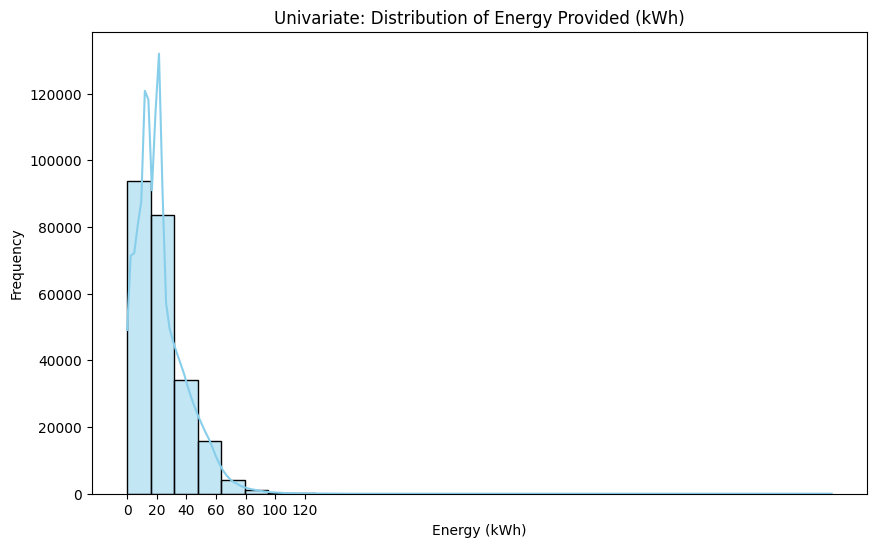

In [ ]:
#Univariate Visualization 1
plt.figure(figsize=(10, 6))
sns.histplot(df['Energy Provided (kWh)'], bins = 30, kde=True, color='skyblue')
plt.xticks(np.arange(0, 121, 20))
plt.title('Univariate: Distribution of Energy Provided (kWh)')
plt.xlabel('Energy (kWh)')
plt.ylabel('Frequency')
plt.savefig('univariate_energy.png')
plt.show()

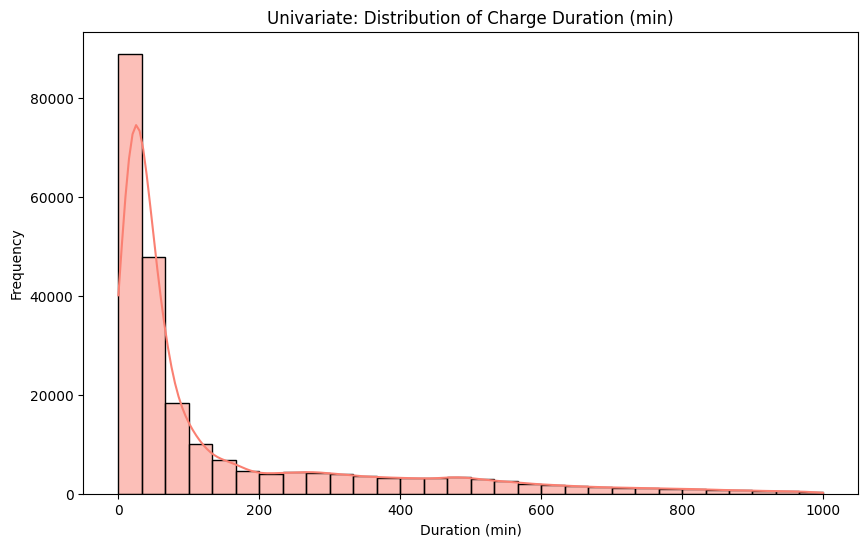

In [ ]:
#Univariate Visualization 2
plt.figure(figsize=(10, 6))
sns.histplot(df['Charge Duration (min)'], bins=30, kde=True, color='salmon')
plt.title('Univariate: Distribution of Charge Duration (min)')
plt.xlabel('Duration (min)')
plt.ylabel('Frequency')
plt.savefig('univariate_duration.png')
plt.show()

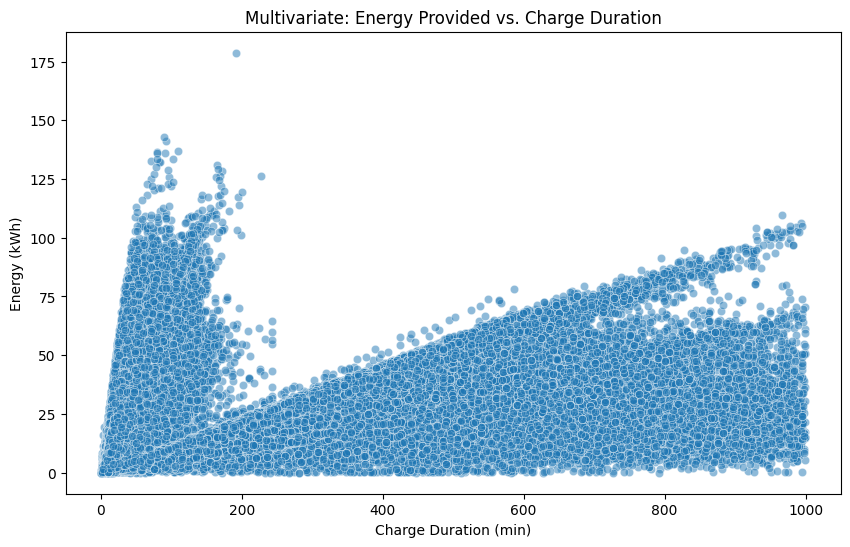

In [ ]:
# MULTIVARIATE VISUALIZATION 1
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Charge Duration (min)', y='Energy Provided (kWh)', alpha=0.5)
plt.title('Multivariate: Energy Provided vs. Charge Duration')
plt.xlabel('Charge Duration (min)')
plt.ylabel('Energy (kWh)')
plt.savefig('multivariate_scatter.png')
plt.show()

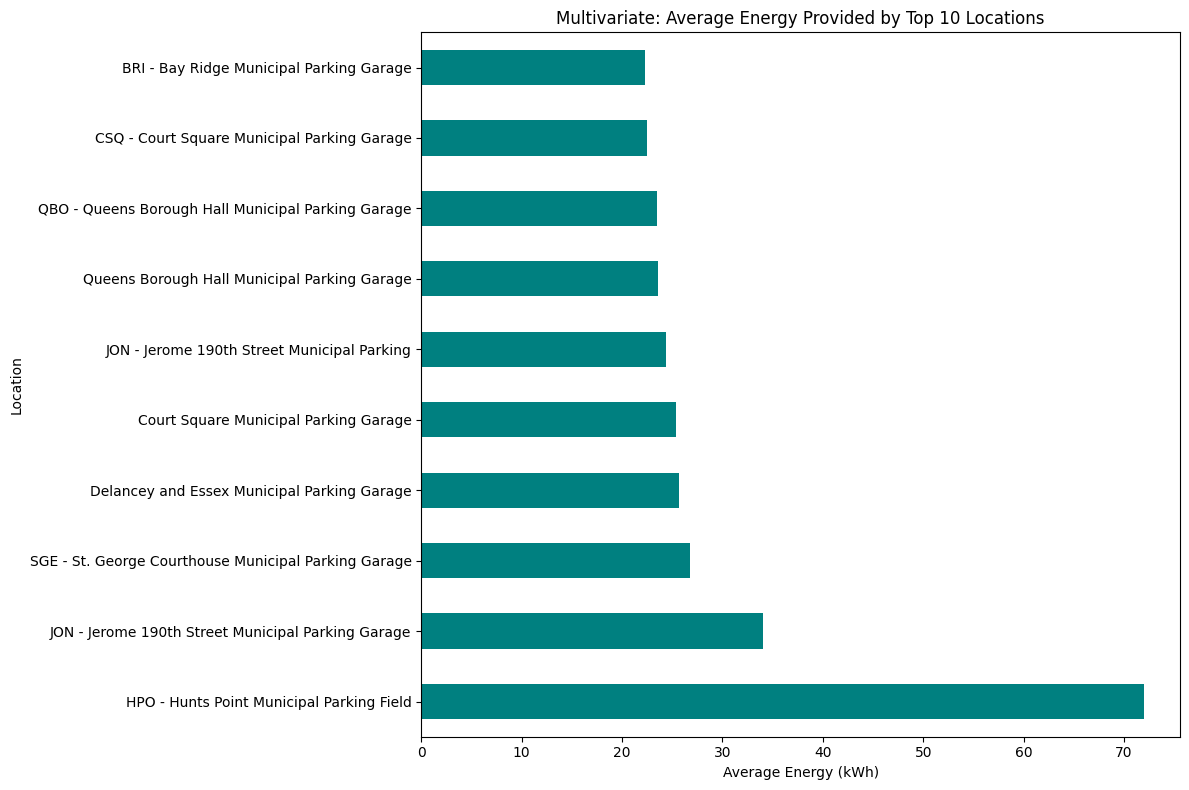

In [ ]:
# MULTIVARIATE VISUALIZATION 2
avg_energy_loc = df.groupby('Location Name')['Energy Provided (kWh)'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 8))
avg_energy_loc.plot(kind='barh', color='teal')
plt.title('Multivariate: Average Energy Provided by Top 10 Locations')
plt.xlabel('Average Energy (kWh)')
plt.ylabel('Location')
plt.tight_layout()
plt.savefig('multivariate_location.png')
plt.show()

In [ ]:
# Convert Date to datetime and extract features
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

# Extract hour from Connected Time
df['Connected Hour'] = pd.to_datetime(df['Connected Time'], format='%H:%M:%S.%f', errors='coerce').dt.hour

# Drop columns with too many NaNs or identifiers not useful for regression
# Driver ID and ID Tag are identifiers. Invalidity Reason is mostly NaN.
df_ml = df[['Location Name', 'Month', 'DayOfWeek', 'Connected Hour', 'Energy Provided (kWh)', 'Charge Duration (min)']].dropna()

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

# --- MACHINE LEARNING ---
X = df_ml[['Location Name', 'Month', 'DayOfWeek', 'Connected Hour', 'Charge Duration (min)']]
y = df_ml['Energy Provided (kWh)']

# Preprocessing
categorical_features = ['Location Name']
numeric_features = ['Month', 'DayOfWeek', 'Connected Hour', 'Charge Duration (min)']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model 1: Random Forest (Classical)
rf_model = Pipeline(steps=[('preprocessor', preprocessor),
                           ('regressor', RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))])
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Model 2: Neural Network (MLP)
mlp_model = Pipeline(steps=[('preprocessor', preprocessor),
                            ('regressor', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42))])
mlp_model.fit(X_train, y_train)
y_pred_mlp = mlp_model.predict(X_test)

# Evaluation
metrics = {
    'RF': {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        'R2': r2_score(y_test, y_pred_rf),
        'MAE': mean_absolute_error(y_test, y_pred_rf)
    },
    'MLP': {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_mlp)),
        'R2': r2_score(y_test, y_pred_mlp),
        'MAE': mean_absolute_error(y_test, y_pred_mlp)
    }
}

print(metrics)

{'RF': {'RMSE': np.float64(11.99008456674344), 'R2': 0.473248257158014, 'MAE': 7.764786515151516}, 'MLP': {'RMSE': np.float64(11.675944005058307), 'R2': 0.5004884946243238, 'MAE': 8.209533979667375}}


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
import gradio as gr
import pandas as pd

# Get unique location names for the dropdown
location_options = df_ml['Location Name'].unique().tolist()

def predict_energy(location, month, day_of_week, connected_hour, charge_duration):
    # Create a DataFrame with the input features, matching the training data structure
    input_df = pd.DataFrame([[location, month, day_of_week, connected_hour, charge_duration]],
                              columns=['Location Name', 'Month', 'DayOfWeek', 'Connected Hour', 'Charge Duration (min)'])

    # Make prediction using the trained Random Forest model
    # The rf_model pipeline already includes the preprocessor
    prediction = rf_model.predict(input_df)[0]
    return f"{prediction:.2f} kWh"

# Gradio Interface
iface = gr.Interface(
    fn=predict_energy,
    inputs=[
        gr.Dropdown(location_options, label="Location Name"),
        gr.Slider(minimum=1, maximum=12, step=1, value=8, label="Month"),
        gr.Slider(minimum=0, maximum=6, step=1, value=3, label="Day of Week (0=Monday, 6=Sunday)"),
        gr.Slider(minimum=0, maximum=23, step=1, value=12, label="Connected Hour"),
        gr.Slider(minimum=0, maximum=720, step=1, value=120, label="Charge Duration (min)")
    ],
    outputs=gr.Textbox(label="Predicted Energy Provided"),
    title="EV Charging Energy Prediction",
    description="Predict the energy provided (kWh) based on charging session parameters."
)

# To run the Gradio app within Colab, use share=True
iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://794dd805b50d58ef4a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
